<img src="https://gitlab.com/bivl2ab/academico/cursos-uis/ai/ai-uis-student/raw/master/imgs/imageClassification.jpeg" alt="Drawing" style="width:1700px;">


# <center> 09. Image classification! </center>


## <span style="color:red"> Outline </span> 
1. **Working with an image dataset: mnist**
2. **Image classification**
3. **Image representation for classification**


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
%matplotlib inline

## <span style="color:green"> If you are in colaboratoy </span>: 

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
%cd drive/My Drive/ai-uis-student/notebooks
!pwd

## <span style="color:red"> 1. Working with an image dataset: mnists </span> 

**Load and explore the dataset!**

Mnist has a set of  handwritten digit images with an specific recognition task challenge. Each row has 785 values, the first column corresponds to the digitl label, and the 784 rest values is a vectorized image of $28 \times 28 $. So, we need to form $\mathbf{X}$ matrix and the corresponding $\mathbf{y}$ vector. Each pixel has an intensity of $[ 0 - 255 ]$

In [4]:
mnist = pd.read_csv("../data/mnist1.5k.csv.gz", header=None).values.astype(float)
print( "dimension de los datos originales", mnist.shape)
X=mnist[:,1:785]
y=mnist[:,0]
print( "dimension de las imagenes y las clases", X.shape, y.shape)
print( "luminosidad maxima", np.max(X))
print( "luminosidad minimo", np.min(X))

dimension de los datos originales (1500, 785)
dimension de las imagenes y las clases (1500, 784) (1500,)
luminosidad maxima 255.0
luminosidad minimo 0.0


Now, we will show some random examples of digits. We use `reshape` to convert a vector of 784 elements in a matrix of size: $(28 \times 28)$ and we interpolate to better visualize the images.

[1013  974  830 ...  625  227 1070]
(50, 784)


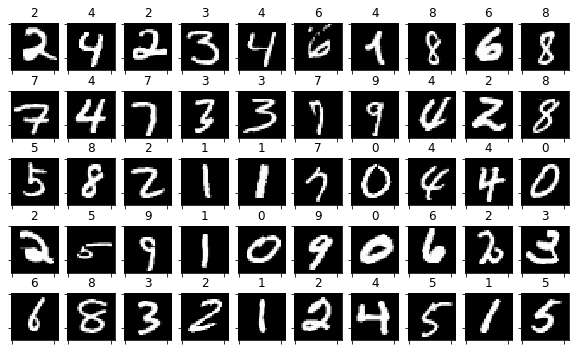

In [11]:
perm = np.random.permutation(range(X.shape[0]))[0:50]
random_imgs   = X[perm]
random_labels = y[perm] 
fig = plt.figure(figsize=(10,6))
for i in range(random_imgs.shape[0]):
    ax=fig.add_subplot(5,10,i+1)
    plt.imshow(random_imgs[i].reshape(28,28), interpolation="nearest", cmap = plt.cm.Greys_r)
    ax.set_title(int(random_labels[i]))
    ax.set_xticklabels([])
    ax.set_yticklabels([])

Now we can see the distribution of classes, i.e., how many images we have for each digit

## <span style="color:orange">student</span>: 
- How is the distribution class?
- Is it a balanced dataset?

In [13]:
for i in np.unique(y):
    print( i, np.sum(y==i))

0.0 150
1.0 157
2.0 186
3.0 125
4.0 151
5.0 138
6.0 152
7.0 154
8.0 141
9.0 146


In [14]:
print( "digito   número de imágenes")
for i in np.unique(y):
    print( "   ",int(i), "   ", np.sum(y==i))

digito   número de imágenes
    0     150
    1     157
    2     186
    3     125
    4     151
    5     138
    6     152
    7     154
    8     141
    9     146


## <span style="color:red"> 2. Image classification </span> 

** Training and prediction **
Firstly we use the **Naive Bayes** algorithm for classification. For fast evaluation, we split the dataset on $80\%$ for training and the rest $20 \%$ for test. 

## <span style="color:orange">student</span>: 
- How is the algorithm performance?
- Is it appropiate for digit classification
- In which digit classes has more mistakes?
- Why?

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
test_size = 0.2
#by defautl is 0.25 in test.

d_train, d_test, c_train, c_test = train_test_split(X, y, test_size=test_size)
print( d_train.shape, d_test.shape)
print( c_train.shape, c_test.shape)

g = SVC(kernel ='rbf')
g.fit(d_train, c_train)
print( "acierto en train", g.score(d_train, c_train))
print( "acierto en test ", g.score(d_test, c_test))


(1200, 784) (300, 784)
(1200,) (300,)
acierto en train 1.0
acierto en test  0.13333333333333333


In [25]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix
from sklearn.svm import SVC
test_size = 0.2

d_train, d_test, c_train, c_test = train_test_split(X,y,test_size=test_size)

print( "dimensiones train", d_train.shape, c_train.shape)
print( "dimsensions test ", d_test.shape, c_test.shape)

g = SVC(kernel='rbf')
g.fit(d_train, c_train)
print( "acierto en train", g.score(d_train, c_train))
print( "acierto en test ", g.score(d_test, c_test))

predicciones_train = g.predict(d_train)
predicciones_test  = g.predict(d_test)

cm_train=confusion_matrix(c_train, predicciones_train)
cm_test = confusion_matrix(c_test, predicciones_test)
print( "matrix de confusión en train\n", cm_train)
print ("matrix de confusión en test\n", cm_test)
print( "verifica número de imágenes en total por fila")
print( np.sum(cm_test, axis=1))

dimensiones train (1200, 784) (1200,)
dimsensions test  (300, 784) (300,)
acierto en train 1.0
acierto en test  0.13333333333333333
matrix de confusión en train
 [[117   0   0   0   0   0   0   0   0   0]
 [  0 117   0   0   0   0   0   0   0   0]
 [  0   0 146   0   0   0   0   0   0   0]
 [  0   0   0 100   0   0   0   0   0   0]
 [  0   0   0   0 122   0   0   0   0   0]
 [  0   0   0   0   0 115   0   0   0   0]
 [  0   0   0   0   0   0 124   0   0   0]
 [  0   0   0   0   0   0   0 130   0   0]
 [  0   0   0   0   0   0   0   0 112   0]
 [  0   0   0   0   0   0   0   0   0 117]]
matrix de confusión en test
 [[ 0  0 33  0  0  0  0  0  0  0]
 [ 0  0 40  0  0  0  0  0  0  0]
 [ 0  0 40  0  0  0  0  0  0  0]
 [ 0  0 25  0  0  0  0  0  0  0]
 [ 0  0 29  0  0  0  0  0  0  0]
 [ 0  0 23  0  0  0  0  0  0  0]
 [ 0  0 28  0  0  0  0  0  0  0]
 [ 0  0 24  0  0  0  0  0  0  0]
 [ 0  0 29  0  0  0  0  0  0  0]
 [ 0  0 29  0  0  0  0  0  0  0]]
verifica número de imágenes en total por fila
[

In [26]:
c_test

array([2., 5., 2., 8., 0., 6., 0., 6., 7., 5., 7., 6., 2., 6., 2., 4., 5.,
       8., 4., 6., 2., 2., 9., 9., 8., 4., 8., 4., 6., 1., 4., 5., 1., 9.,
       1., 2., 8., 5., 7., 8., 1., 9., 1., 0., 4., 2., 1., 3., 8., 8., 2.,
       0., 5., 6., 5., 8., 2., 1., 7., 1., 9., 0., 6., 5., 5., 1., 5., 3.,
       2., 2., 3., 2., 4., 9., 7., 9., 7., 6., 2., 8., 8., 2., 4., 6., 1.,
       2., 8., 3., 3., 2., 1., 3., 2., 1., 2., 1., 9., 8., 1., 0., 3., 7.,
       7., 9., 5., 1., 7., 9., 0., 1., 2., 2., 9., 1., 2., 1., 9., 0., 2.,
       4., 2., 5., 3., 2., 7., 0., 1., 2., 8., 4., 7., 6., 6., 0., 9., 8.,
       7., 4., 4., 0., 0., 1., 6., 8., 9., 1., 5., 2., 2., 9., 9., 0., 7.,
       9., 7., 9., 6., 1., 1., 4., 9., 7., 9., 1., 5., 4., 7., 6., 2., 2.,
       2., 0., 5., 4., 1., 8., 4., 0., 1., 0., 3., 5., 8., 7., 1., 1., 3.,
       9., 1., 6., 3., 2., 0., 3., 3., 8., 3., 1., 3., 9., 9., 5., 1., 5.,
       0., 5., 1., 6., 5., 1., 6., 0., 3., 4., 1., 7., 0., 0., 1., 3., 6.,
       2., 6., 9., 8., 4.

In [27]:
predicciones_test

array([2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2.,
       2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2.,
       2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2.,
       2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2.,
       2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2.,
       2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2.,
       2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2.,
       2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2.,
       2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2.,
       2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2.,
       2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2.,
       2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2.,
       2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2.,
       2., 2., 2., 2., 2.

cross validated classification

In [14]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import *

s = cross_val_score(GaussianNB(), X, y, cv=KFold(5, shuffle=True), scoring=make_scorer(accuracy_score))
print "accuracy %.3f (+/- %.5f)"%(np.mean(s), np.std(s))

accuracy 0.596 (+/- 0.02407)


In [17]:
from sklearn.ensemble import RandomForestClassifier
s = cross_val_score(SVC(kernel='poly'), X, y, cv=KFold(5, shuffle=True), scoring=make_scorer(accuracy_score))
print "accuracy %.3f (+/- %.5f)"%(np.mean(s), np.std(s))

accuracy 0.897 (+/- 0.01011)


## <span style="color:red"> 3. Image representation for classification </span> 

We can use hundreds of matemathical representations for images. For instance, we can use the histogram of gray levels. This representation is a vector of 255 values, in which each value has a count of hom many pixels there exist for each intensity.

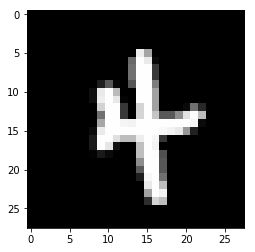

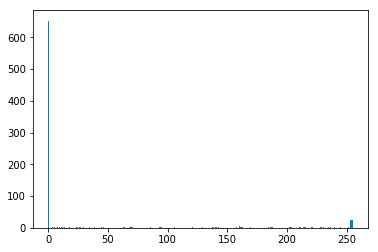

In [28]:
random_idx = np.random.randint(X.shape[0])
hist = np.histogram(X[random_idx], bins=255)[0];
plt.imshow(X[random_idx].reshape(28,28),interpolation="nearest", cmap = plt.cm.Greys_r);
plt.figure();
plt.hist(X[random_idx], bins=255);

we can represent whole images  as hitograms

In [30]:
d_hist = np.zeros((X.shape[0], 255))
for i in range(X.shape[0]):
    d_hist[i] = np.histogram(X[i], bins=255)[0]
print( d_hist.shape)

(1500, 255)


In [20]:
s = cross_val_score(GaussianNB(), d_hist, y, cv=KFold(5, shuffle=True), scoring=make_scorer(accuracy_score))
print("accuracy %.3f (+/- %.5f)"%(np.mean(s), np.std(s))) 

accuracy 0.202 (+/- 0.01916)


In [15]:
s = cross_val_score(RandomForestClassifier(), d_hist, y, cv=KFold(5, shuffle=True), scoring=make_scorer(accuracy_score))
print "accuracy %.3f (+/- %.5f)"%(np.mean(s), np.std(s))

accuracy 0.189 (+/- 0.01439)


## <span style="color:orange">student</span>: 
- Why histograms are not a proper representation in this task?

# Usamos un PCA

In [22]:
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

p = Pipeline((("pca", PCA(n_components=50)), ("classifier", GaussianNB()) ))
s = cross_val_score(p, X, y, cv=KFold(5, shuffle=True), scoring=make_scorer(accuracy_score))
print "accuracy %.3f (+/- %.5f)"%(np.mean(s), np.std(s))

 accuracy 0.836 (+/- 0.01948)


We can perform tunning about components

In [23]:
n_components = range(10,160,10)
means, stds = [], []
for n in n_components:
    print n,
    p = Pipeline((("pca", PCA(n_components=n)), ("classifier", SVC(kernel= 'poly')) ))
    s = cross_val_score(p, X, y, cv=KFold(5, shuffle=True), scoring=make_scorer(accuracy_score))
    means.append(np.mean(s))
    stds.append(np.std(s))
means = np.r_[means]
stds  = np.r_[stds]


10 20 30 40 50 60 70 80 90 100 110 120 130 140 150


Text(0.5,1,u'GaussianNB')

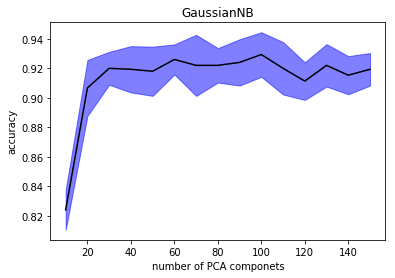

In [24]:
plt.plot(n_components, means, color="black")
plt.fill_between(n_components, means-stds, means+stds, color="blue", alpha=.5)
plt.xlabel("number of PCA componets")
plt.ylabel("accuracy")
plt.title("GaussianNB")

In [19]:
p = Pipeline((("pca", PCA(n_components=100)), ("classifier", RandomForestClassifier()) ))
s = cross_val_score(p, X, y, cv=KFold(5, shuffle=True), scoring=make_scorer(accuracy_score))
print "accuracy %.3f (+/- %.5f)"%(np.mean(s), np.std(s))

accuracy 0.697 (+/- 0.03065)


In [20]:
n_components = range(10,160,10)
means, stds = [], []
for n in n_components:
    print n,
    p = Pipeline((("pca", PCA(n_components=n)), ("classifier", RandomForestClassifier()) ))
    s = cross_val_score(p, X, y, cv=KFold(10, shuffle=True), scoring=make_scorer(accuracy_score))
    means.append(np.mean(s))
    stds.append(np.std(s))
means = np.r_[means]
stds  = np.r_[stds]

10 20 30 40 50 60 70 80 90 100 110 120 130 140 150


Text(0.5,1,u'RandomForestClassifier')

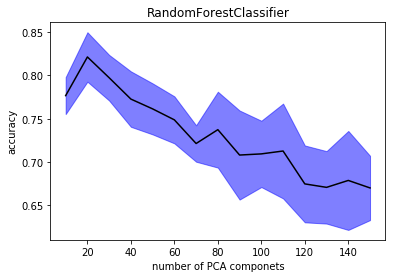

In [21]:
plt.plot(n_components, means, color="black")
plt.fill_between(n_components, means-stds, means+stds, color="blue", alpha=.5)
plt.xlabel("number of PCA componets")
plt.ylabel("accuracy")
plt.title("RandomForestClassifier")

## <span style="color:orange">student</span>: 

- Can we use other image representation?
- What about convolution?

# References

[1] Imagenet: http://www.image-net.org/


[2] Not NMIST: http://yaroslavvb.blogspot.com/2011/09/notmnist-dataset.html

http://yaroslavvb.com/upload/notMNIST/



---
<img src="https://gitlab.com/bivl2ab/academico/cursos-uis/ai/ai-uis-student/raw/master/imgs/bannerThanks.jpg" alt="Drawing" style="width:700px;">
